# Phase 4 - Model Evaluation & Explainability

*Hospital Operations & Revenue Risk Intelligence Platform*

**Goal:** prove the two Phase 3 classifiers are interpretable, reliable and safe
to deploy - and turn Model B into an operating decision.

This notebook evaluates the **persisted Phase 3 models as-is** (nothing is
retrained or retuned; the leakage ablation trains throwaway variants for
evidence only). It is thin: all reusable logic lives in `capstone.evaluation`;
the per-finding charts are in `phase4_eval/make_charts.py` and the report /
model-card assembler in `phase4_eval/report.py`. It runs top-to-bottom from a
clean kernel and is safe to re-run.

**Inputs:** `phase3_models/models/` (pipelines, calibrated wrappers,
`training_manifest.json`), `phase2_eda/output/feature_frame.parquet`,
`capstone_solution.v_visit_billing` (for reporting-only money fields).
**Outputs:** `phase4_eval/output/` (CSVs, `charts/`),
`phase4_eval/PHASE4_FINDINGS.md`, `phase4_eval/model_card_A.md`,
`phase4_eval/model_card_B.md`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from capstone import evaluation as E, modeling as M, features as feat, viz
import make_charts, report

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
viz.apply_house_style()

HERE = Path.cwd()
OUT = HERE / "output"; (OUT / "charts").mkdir(parents=True, exist_ok=True)
PARQUET = HERE.parent / "phase2_eda" / "output" / "feature_frame.parquet"
FINDINGS_MD = HERE / "PHASE4_FINDINGS.md"

## 1. Load the Phase 2 frame, the spine, and the persisted Phase 3 models

Same calendar-anchored `visit_date` split as Phase 3 (9 months train / 1 validate / 2 test). The spine is joined only for the reporting-only money fields (`billed_amount` / `approved_amount` / `leakage_amount` / `payment_days`) - never model inputs.

In [2]:
from capstone import eda

df = pd.read_parquet(PARQUET)
df["visit_date"] = pd.to_datetime(df["visit_date"])
splits = M.time_split(df)
spine = eda.load_spine()
art = E.load_phase3()
manifest = art["manifest"]
print("model_version", manifest["model_version"], "| splits:")
splits.describe()

model_version 1.0.0 | splits:


,split,rows,start,end
0,train,18665,2025-01-20,2025-10-19
1,val,2075,2025-10-20,2025-11-19
2,test,4260,2025-11-20,2026-01-20


### 1.1 Leakage self-check + reload parity

The Phase 2 register still holds, and the reloaded artefacts still reproduce their predictions - the Phase 3 exit criteria, re-verified here before we build anything on them.

In [3]:
violations = feat.leakage_violations(splits.train)
assert not violations, violations
print("leakage register: clean")

# reload each artefact a second time from disk and confirm identical predictions
rows = []
for k in ("A", "B"):
    Xk = splits.test[sum(M.feature_lists(splits.train, k), [])]
    p2 = M.load_model(art["models_dir"], k, calibrated=False)
    c2 = M.load_model(art["models_dir"], k, calibrated=True)
    rows.append({"model": f"Model {k}", "n_test_rows": len(Xk),
                 "labels_match": bool((p2.predict(Xk) == art[k]["pipeline"].predict(Xk)).all()),
                 "proba_match": bool(np.allclose(c2.predict_proba(Xk),
                                                 art[k]["calibrated"].predict_proba(Xk)))})
parity = pd.DataFrame(rows)
display(parity)
assert parity[["labels_match", "proba_match"]].all().all()

leakage register: clean


,model,n_test_rows,labels_match,proba_match
0,Model A,4260,True,True
1,Model B,4260,True,True


## 2. Prediction frames and per-class metrics

One row per test-window visit: the uncalibrated pipeline label (the Phase 3 default), the calibrated class probabilities, the protected-attribute columns, and the money fields.

In [4]:
preds = {k: E.prediction_frame(splits, k, art, spine) for k in ("A", "B")}
per_class = {k: E.per_class_metrics(preds[k]["actual"], preds[k]["pred_pipeline"],
                                    M.CLASS_ORDER[k]) for k in ("A", "B")}
for k in ("A", "B"):
    display(Markdown(f"**Model {k} - per-class metrics (test window)**"))
    display(per_class[k])

**Model A - per-class metrics (test window)**

,class,precision,recall,f1,support
0,Low,0.4972,1.0,0.6642,2118
1,Medium,0.0000,0.0,0.0000,1279
2,High,0.0000,0.0,0.0000,863


**Model B - per-class metrics (test window)**

,class,precision,recall,f1,support
0,Paid,0.6935,0.3934,0.5020,2565
1,Pending,0.2838,0.2585,0.2706,1087
2,Rejected,0.2198,0.6562,0.3293,608


In [5]:
roc_pr = {}
for k in ("A", "B"):
    p = preds[k]
    classes = M.CLASS_ORDER[k]
    proba = p[[f"prob_{c.lower()}" for c in classes]].to_numpy()
    roc_pr[k] = E.roc_pr_frame(p["actual"], proba, classes, classes)
rp = (roc_pr["B"].groupby(["cls", "curve"]).agg(auc=("auc", "first"), ap=("ap", "first")).reset_index())
display(Markdown("**Model B one-vs-rest ROC AUC / average precision**"))
display(rp.round(4))

**Model B one-vs-rest ROC AUC / average precision**

,cls,curve,auc,ap
0,Paid,pr,NaN,0.6909
1,Paid,roc,0.5947,NaN
2,Pending,pr,NaN,0.2664
3,Pending,roc,0.5139,NaN
4,Rejected,pr,NaN,0.2315
5,Rejected,roc,0.6776,NaN


## 3. Operating threshold for Model B - maximise net recovered leakage

Sweep the calibrated `P(Rejected)` cut-off on the **validation** month; pick the threshold that maximises recoverable denial leakage on correctly-flagged rejections (with a 40% haircut) minus review cost (Rs. 1,500/claim). Apply it unchanged to the **test** window.

In [6]:
val_split = M.Splits(splits.train, splits.val, splits.val)
pred_val = E.prediction_frame(val_split, "B", art, spine)
sweep_val = E.threshold_sweep(pred_val)
sweep_test = E.threshold_sweep(preds["B"])
chosen = E.choose_threshold(sweep_val)
threshold = float(chosen["threshold"])
business = E.business_summary(preds["B"], threshold)
print(f"operating threshold (chosen on validation): {threshold:.3f}")
display(sweep_val.iloc[::4].round(4))
display(Markdown("**Business impact at the operating threshold (test window)**"))
display(pd.Series(business).to_frame("value").round(2))

operating threshold (chosen on validation): 0.190


,threshold,recall,precision,flagged_n,flagged_rate,leakage_recovered,review_cost_total,net_recovered
0,0.02,0.9941,0.1726,1947,0.9383,2594416.296,2920500.0,-326083.704
4,0.06,0.9438,0.1937,1647,0.7937,2550144.768,2470500.0,79644.768
8,0.10,0.9172,0.2074,1495,0.7205,2452525.384,2242500.0,210025.384
12,0.14,0.8550,0.2292,1261,0.6077,2205761.660,1891500.0,314261.660
16,0.18,0.7337,0.2448,1013,0.4882,2011499.288,1519500.0,491999.288
20,0.22,0.5621,0.2676,710,0.3422,1530939.304,1065000.0,465939.304
24,0.26,0.3550,0.3046,394,0.1899,941417.084,591000.0,350417.084
28,0.30,0.0000,0.0000,1,0.0005,0.000,1500.0,-1500.000
32,0.34,0.0000,0.0000,0,0.0000,0.000,0.0,0.000
36,0.38,0.0000,0.0000,0,0.0000,0.000,0.0,0.000


**Business impact at the operating threshold (test window)**

,value
threshold,0.19
test_rows,4260.00
costly_total,608.00
costly_caught,377.00
recall,0.62
precision,0.22
flagged_n,1699.00
alerts_per_month,847.83
leakage_recovered,3053008.26
leakage_flagged_gross,7632520.64


## 4. Leakage verification by ablation

Retrain Model B's Phase 3 learner (`gbm`) with features dropped, or with a forbidden post-outcome field injected, and score on the test window. `clean (shipped)` should reproduce Phase 3; every `LEAK +` row should spike. Model A is not ablated - it ships as a majority-class baseline that ignores every feature, so it cannot leak (its zero permutation importance in section 5 is the direct evidence).

In [7]:
ablation = {"B": E.leakage_ablation(splits, spine)}
display(Markdown("**Model B - leakage ablation**"))
display(ablation["B"])

**Model B - leakage ablation**

,variant,is_leak,n_features,accuracy,balanced_accuracy,macro_f1,recall_rejected
0,clean (shipped),False,29,0.3965,0.4360,0.3673,0.6562
1,- risk_score,False,28,0.3977,0.4347,0.3666,0.6546
2,- provider history,False,27,0.3974,0.4311,0.3629,0.6562
3,- patient history,False,22,0.3885,0.4345,0.3661,0.6398
4,- billed_amount,False,26,0.3620,0.3421,0.3129,0.1480
5,LEAK + approved_amount,True,30,0.9634,0.9563,0.9607,0.9572
6,LEAK + payment_days,True,30,0.5387,0.4929,0.4627,0.5362


## 5. Explainability - permutation importance + SHAP (Model B)

In [8]:
feat_b = sum(M.feature_lists(splits.train, "B"), [])
perm_importance = {
    "B": E.permutation_importance_frame(art["B"]["pipeline"], splits.test[feat_b],
                                        preds["B"]["actual"]),
    "A": E.permutation_importance_frame(art["A"]["pipeline"],
                                        splits.test[sum(M.feature_lists(splits.train, "A"), [])],
                                        preds["A"]["actual"]),
}
display(Markdown("**Model B - permutation importance (top 12)**"))
display(perm_importance["B"].head(12))
display(Markdown("**Model A - permutation importance (every feature ~0: no signal)**"))
display(perm_importance["A"].head(6))
display(Markdown("**Model A - one-vs-rest ROC AUC (~0.50: constant scores)**"))
display(roc_pr["A"].groupby("cls")["auc"].first().dropna().round(4).to_frame("roc_auc"))

**Model B - permutation importance (top 12)**

,feature,importance_mean,importance_std
0,billed_amount,0.054346,0.007397
1,billed_band,0.029343,0.003584
2,age,0.003341,0.001451
3,prior_visit_count,0.002399,0.001911
4,age_band,0.001782,0.000518
5,provider_prior_rejection_rate,0.001363,0.001733
6,risk_score,0.001168,0.001077
7,doctor_load_30d,0.000718,0.000730
8,chronic_flag,0.000707,0.000873
9,prior_high_risk_count,0.000659,0.000932


**Model A - permutation importance (every feature ~0: no signal)**

,feature,importance_mean,importance_std
0,prior_visit_count,0.0,0.0
1,prior_high_risk_count,0.0,0.0
2,insurance_provider,0.0,0.0
3,city,0.0,0.0
4,gender,0.0,0.0
5,age_band,0.0,0.0


**Model A - one-vs-rest ROC AUC (~0.50: constant scores)**

,roc_auc
cls,
High,0.5
Low,0.5
Medium,0.5


In [9]:
X_b = splits.test[feat_b]
shap_res = E.shap_summary(art["B"]["pipeline"], X_b.sample(min(600, len(X_b)), random_state=0))
shap_local = E.shap_local_rows(preds["B"], shap_res) if shap_res is not None else {}
if shap_res is not None:
    display(Markdown("**Model B - SHAP mean |value| for P(Rejected) (top 10)**"))
    display(shap_res.mean_abs().head(10))
else:
    print("SHAP unavailable this run - permutation importance carries the explainability weight "
          "(documented in the report).")

/Users/devendranalawade/workspace/agents/capstone-project/capstone-healthcare-analytics/solution/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Model B - SHAP mean |value| for P(Rejected) (top 10)**

,feature,mean_abs_shap
0,billed_amount,0.338350
1,billed_band_15k-30k,0.213798
2,billed_band_5k-15k,0.046865
3,provider_prior_claim_count,0.015680
4,visit_type_ICU,0.014142
5,length_of_stay_hours,0.007712
6,prior_visit_count,0.007690
7,days_since_last_visit,0.007199
8,day_of_week,0.006945
9,age,0.006936


## 6. Calibration and fairness

In [10]:
reliability = {
    k: E.reliability_frame(art[k]["pipeline"], art[k]["calibrated"],
                           splits.test[sum(M.feature_lists(splits.train, k), [])],
                           preds[k]["actual"], M.CLASS_ORDER[k])
    for k in ("A", "B")
}
fairness = {"B": E.fairness_all(preds["B"], threshold=threshold)}
display(Markdown("**Model B - fairness parity summary (at the operating threshold)**"))
display(fairness["B"]["summary"].round(3))

**Model B - fairness parity summary (at the operating threshold)**

,group,levels,selection_rate_gap,selection_rate_ratio,recall_gap,recall_ratio,fpr_gap,fpr_ratio,four_fifths_pass
0,gender,2,0.001,0.998,0.009,0.986,0.007,0.981,True
1,age_band,5,0.064,0.851,0.050,0.922,0.072,0.820,True
2,city,6,0.049,0.886,0.203,0.727,0.046,0.882,True
3,insurance_provider,4,0.012,0.970,0.064,0.900,0.011,0.969,True


## 7. Charts, findings and model cards

Every finding is backed by a house-style chart (`capstone.viz`); `make_charts.build_all` also writes the CSV exports.

In [11]:
ctx = E.EvalContext(
    manifest=manifest, review_cost=E.REVIEW_COST,
    preds=preds, per_class=per_class, roc_pr=roc_pr,
    sweep_val=sweep_val, sweep_test=sweep_test, threshold=threshold, business=business,
    ablation=ablation, perm_importance=perm_importance, reliability=reliability,
    fairness=fairness, shap=shap_res, shap_local=shap_local,
)
charts = make_charts.build_all(ctx)
_C = {k: p for k, p, _ in charts}
list(_C)

['per_class_b',
 'confusion_operating_b',
 'roc_b',
 'pr_b',
 'calibration_ab',
 'threshold_sweep_b',
 'net_recovery_b',
 'permutation_importance_b',
 'shap_summary_b',
 'shap_local_b',
 'leakage_ablation',
 'fairness_b',
 'model_a_degeneracy']

### 7.1 Technical metrics

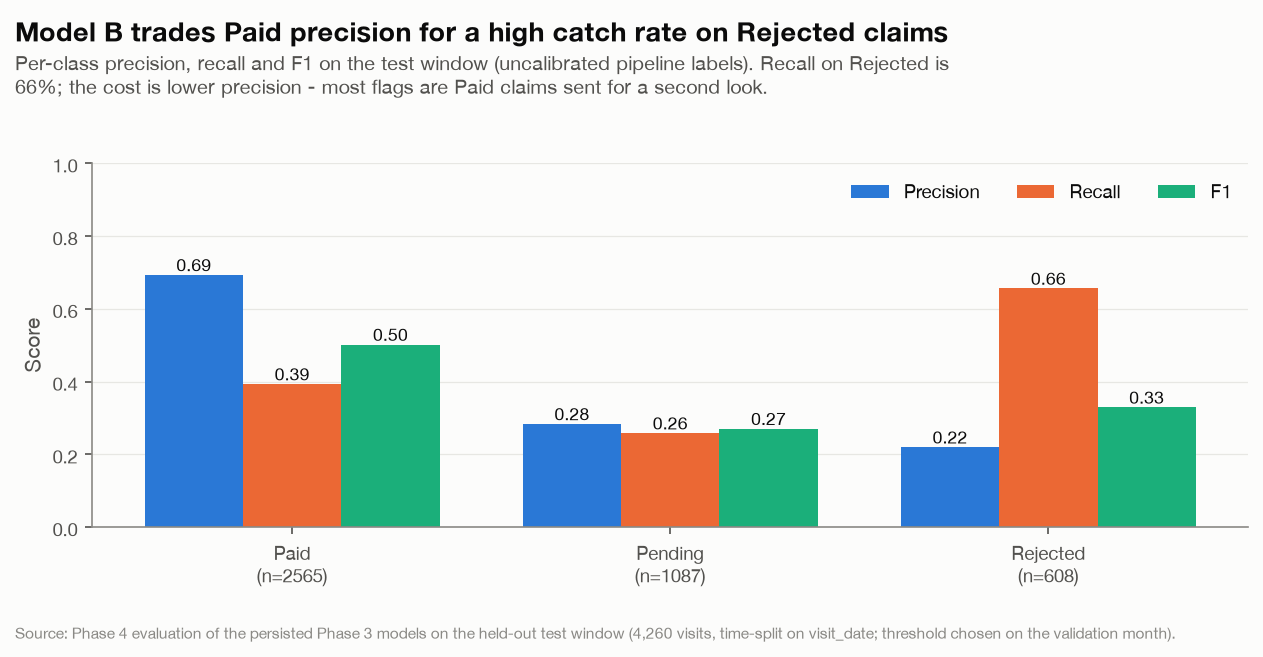

In [12]:
Image(str(_C["per_class_b"]))

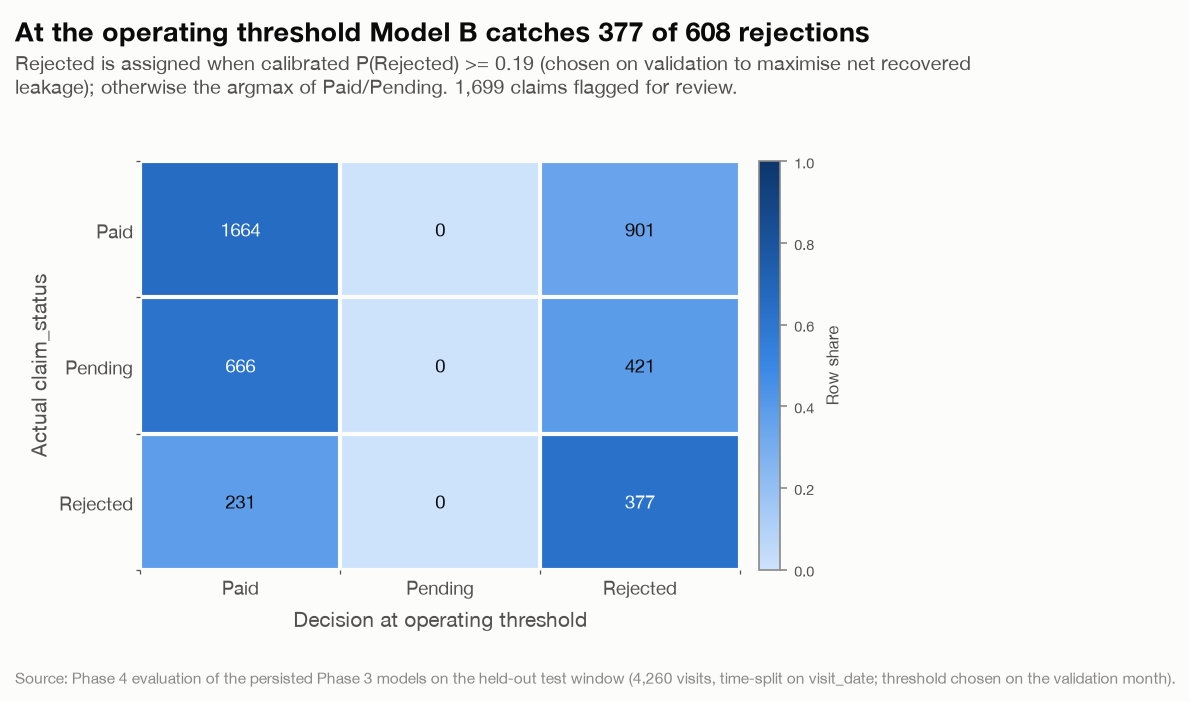

In [13]:
Image(str(_C["confusion_operating_b"]))

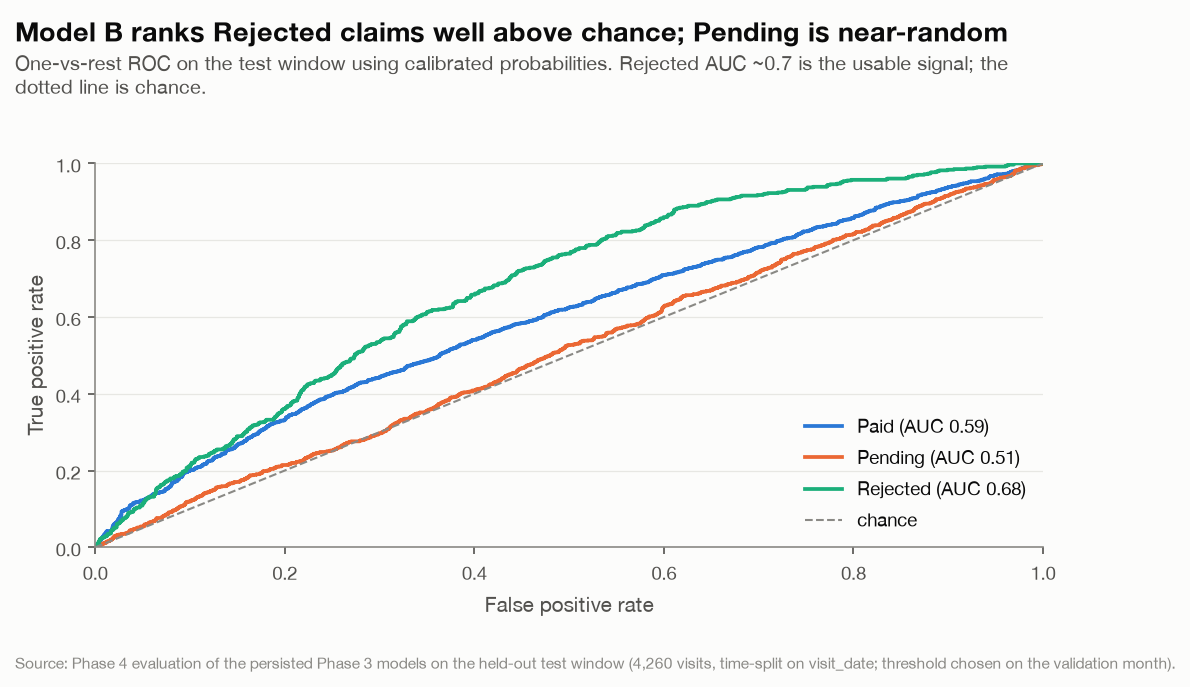

In [14]:
Image(str(_C["roc_b"]))

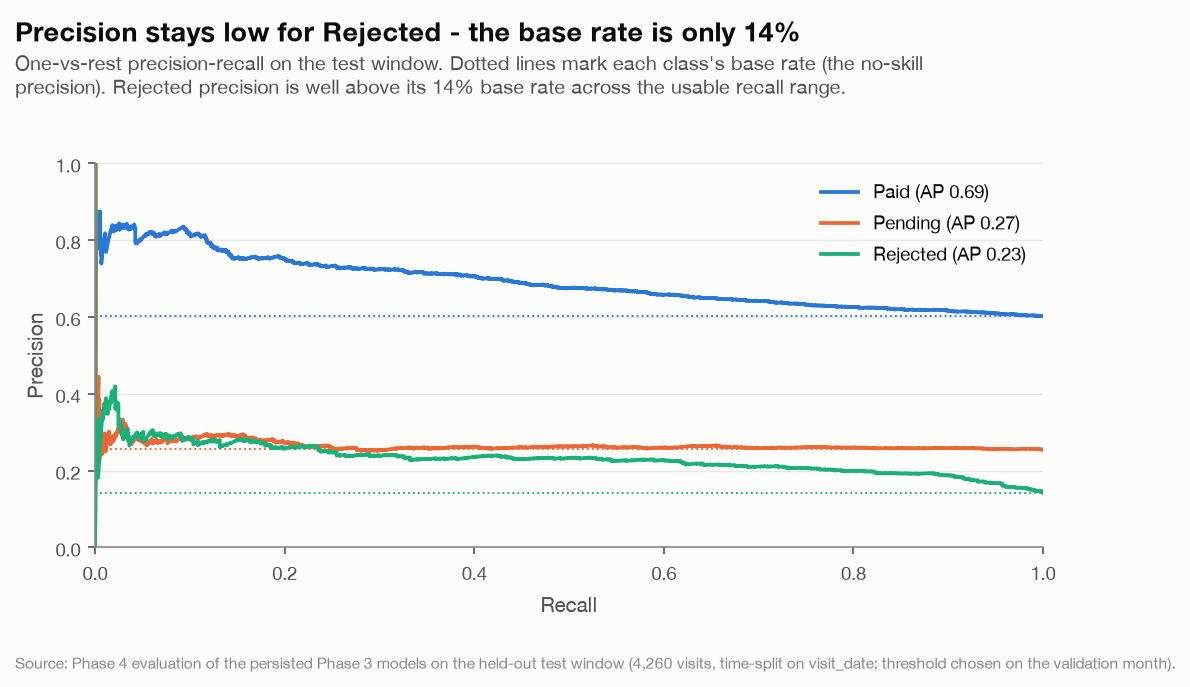

In [15]:
Image(str(_C["pr_b"]))

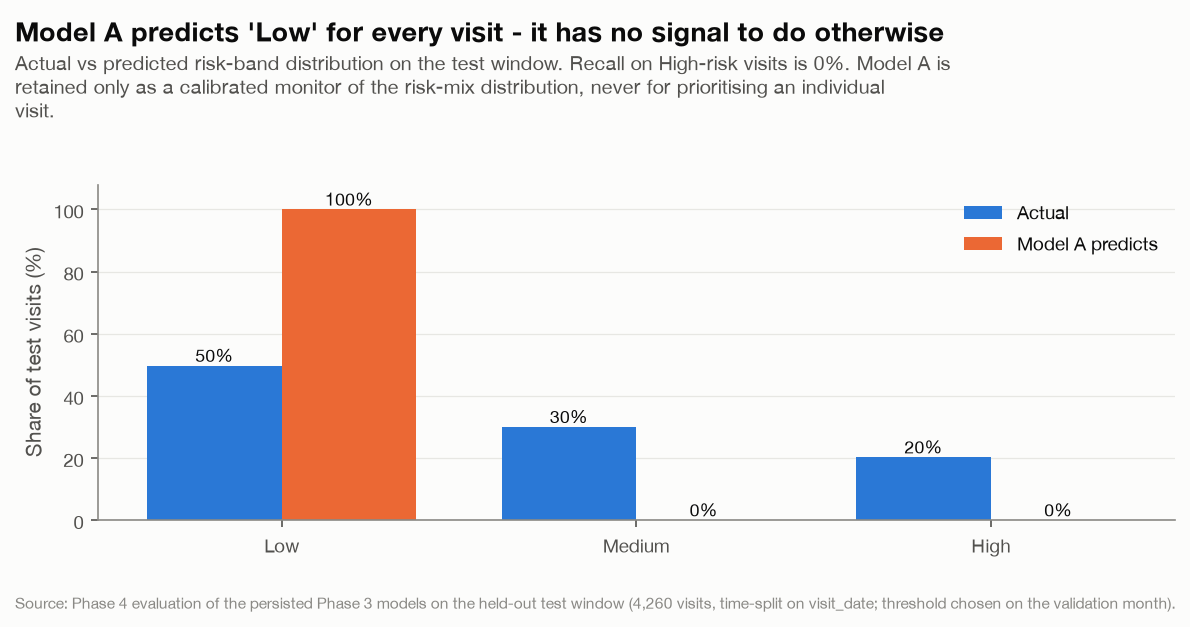

In [16]:
Image(str(_C["model_a_degeneracy"]))

### 7.2 Calibration

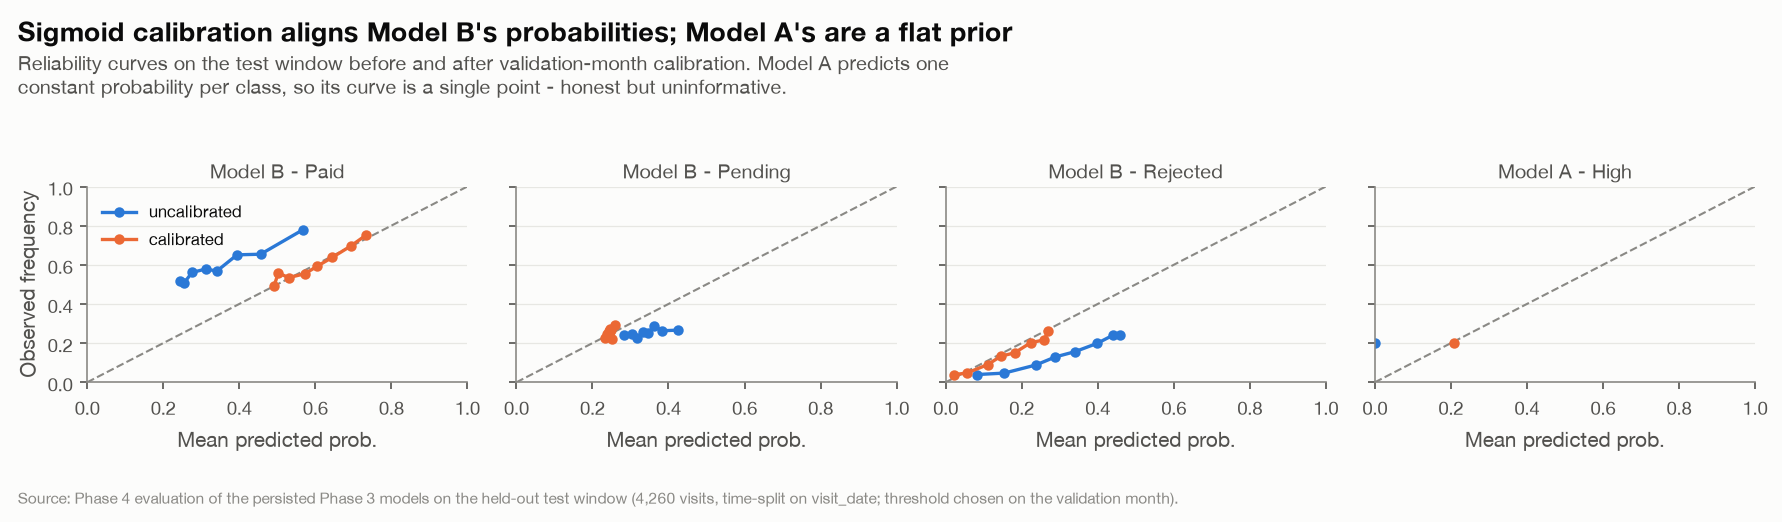

In [17]:
Image(str(_C["calibration_ab"]))

### 7.3 Operating threshold & business impact

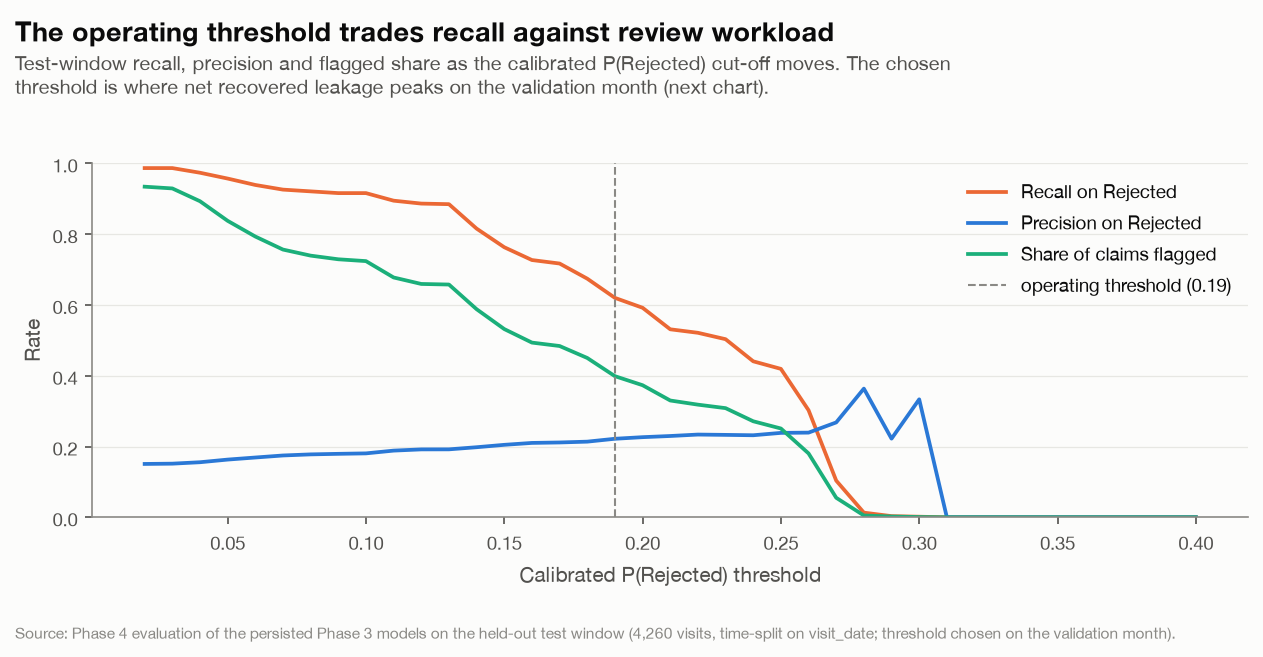

In [18]:
Image(str(_C["threshold_sweep_b"]))

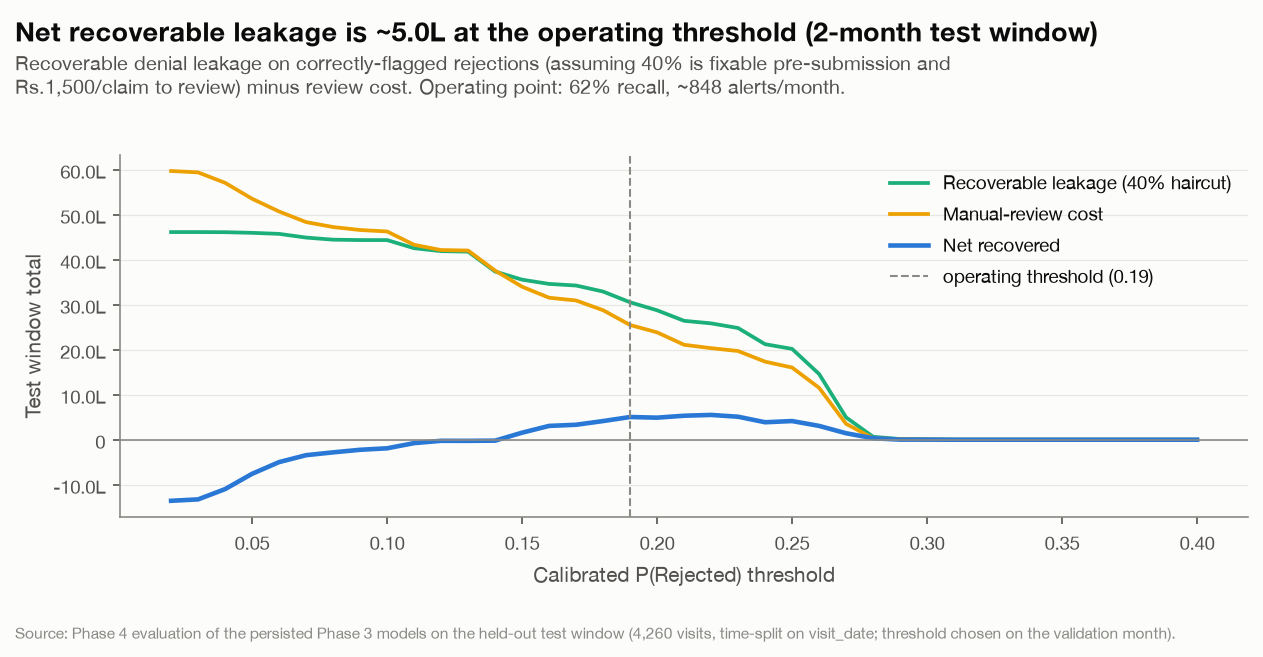

In [19]:
Image(str(_C["net_recovery_b"]))

### 7.4 Explainability

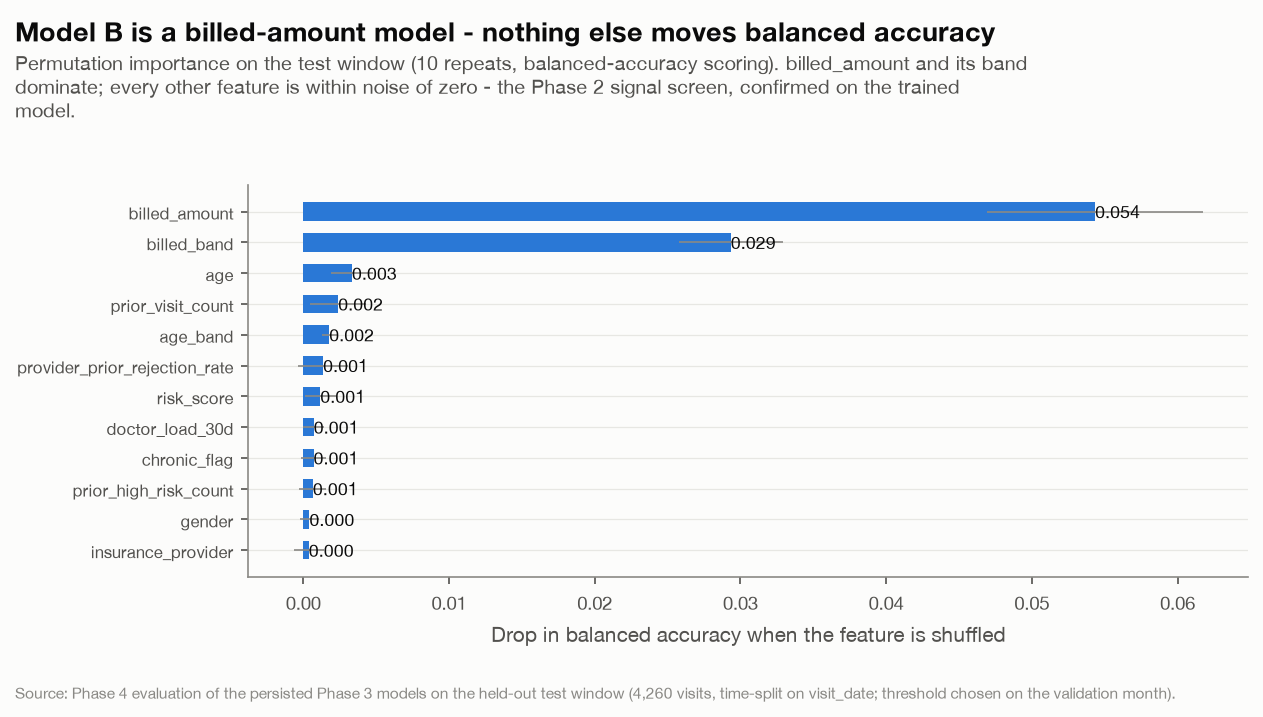

In [20]:
Image(str(_C["permutation_importance_b"]))

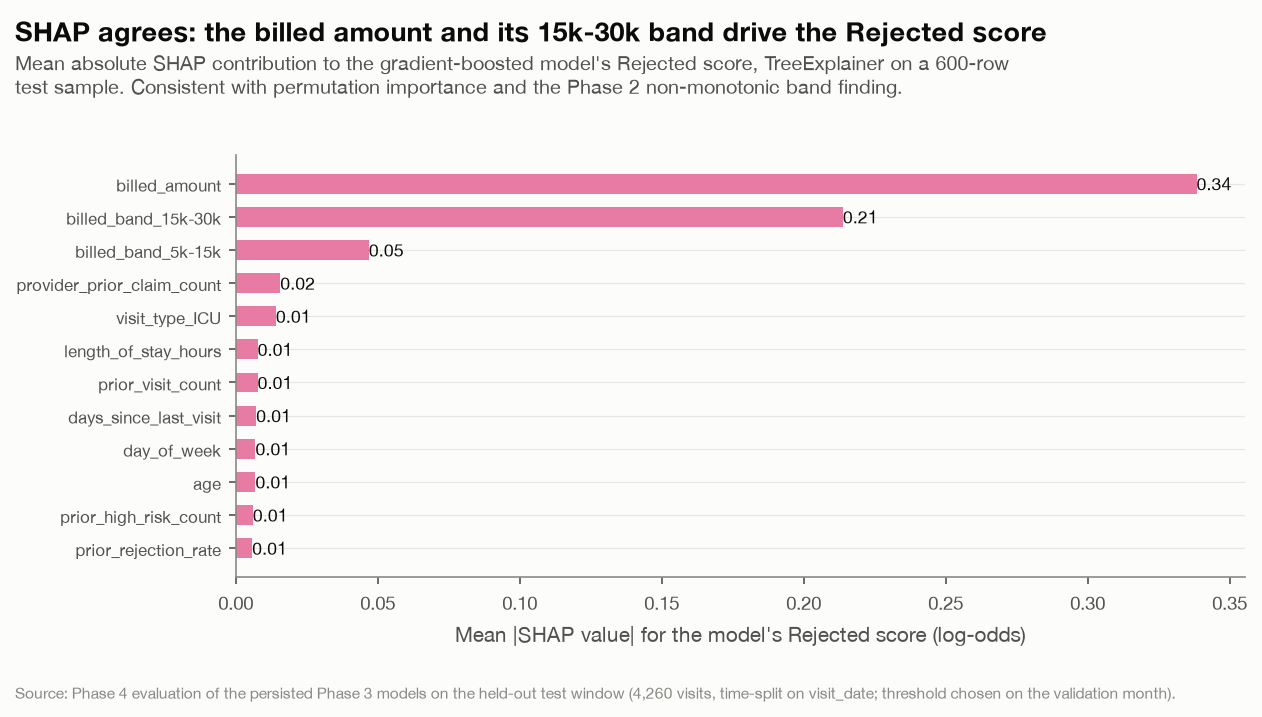

In [21]:
display(Image(str(_C["shap_summary_b"]))) if "shap_summary_b" in _C else print("SHAP summary chart skipped (SHAP unavailable this run).")

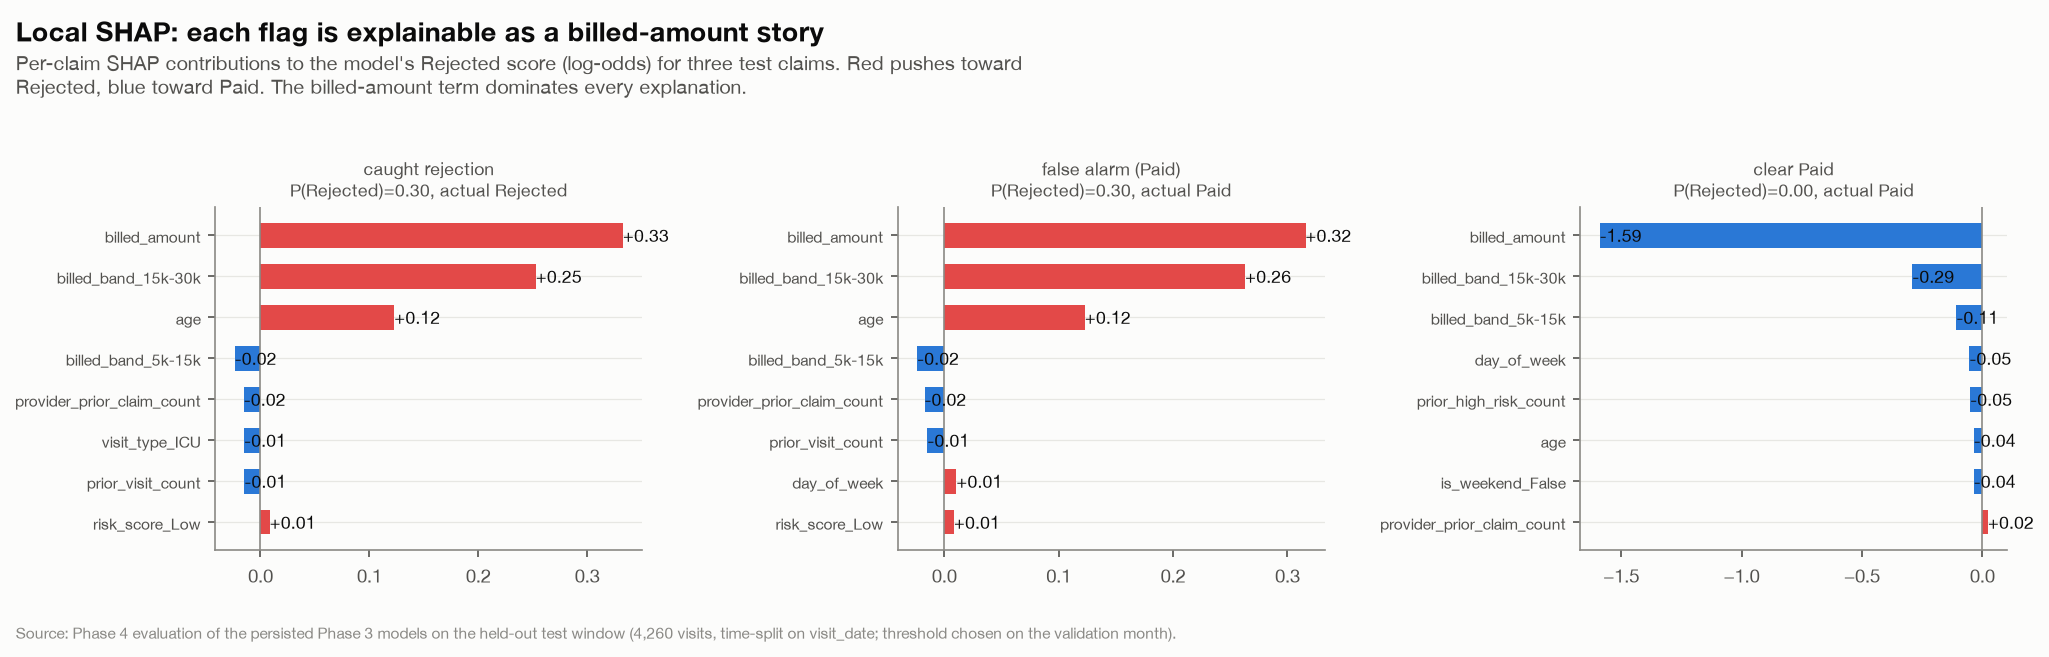

In [22]:
display(Image(str(_C["shap_local_b"]))) if "shap_local_b" in _C else None

### 7.5 Leakage ablation

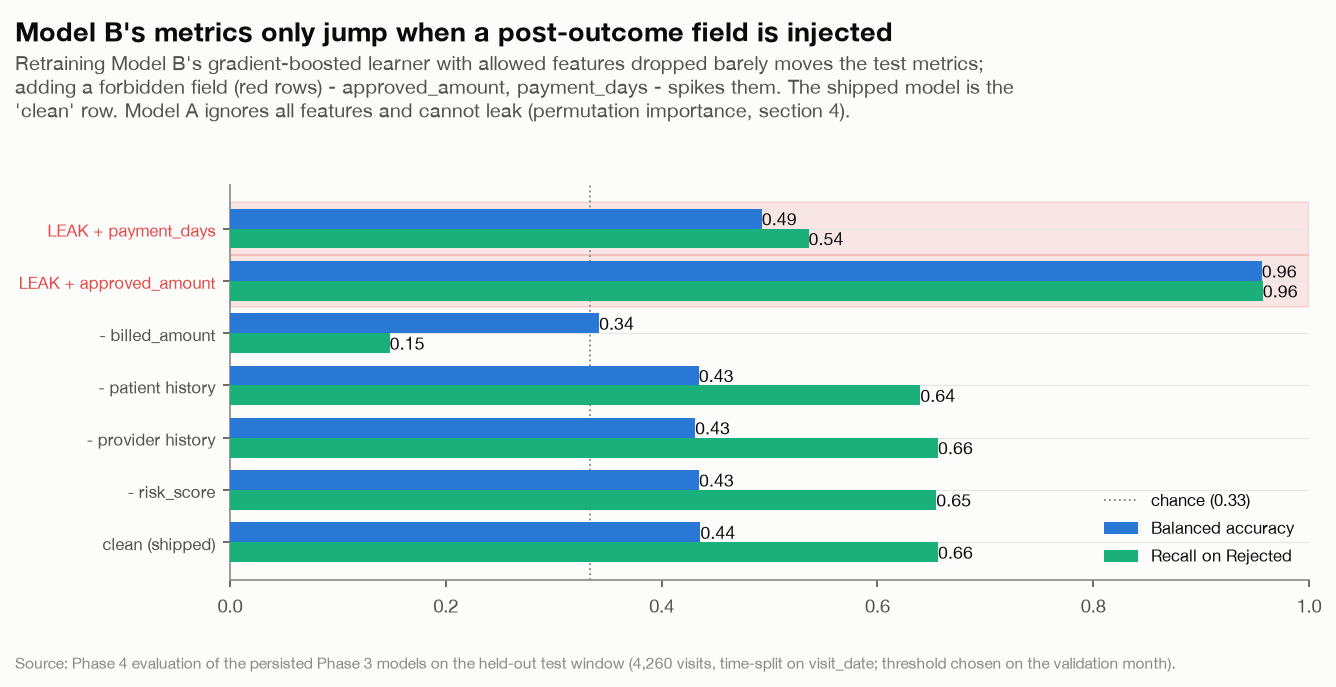

In [23]:
Image(str(_C["leakage_ablation"]))

### 7.6 Fairness

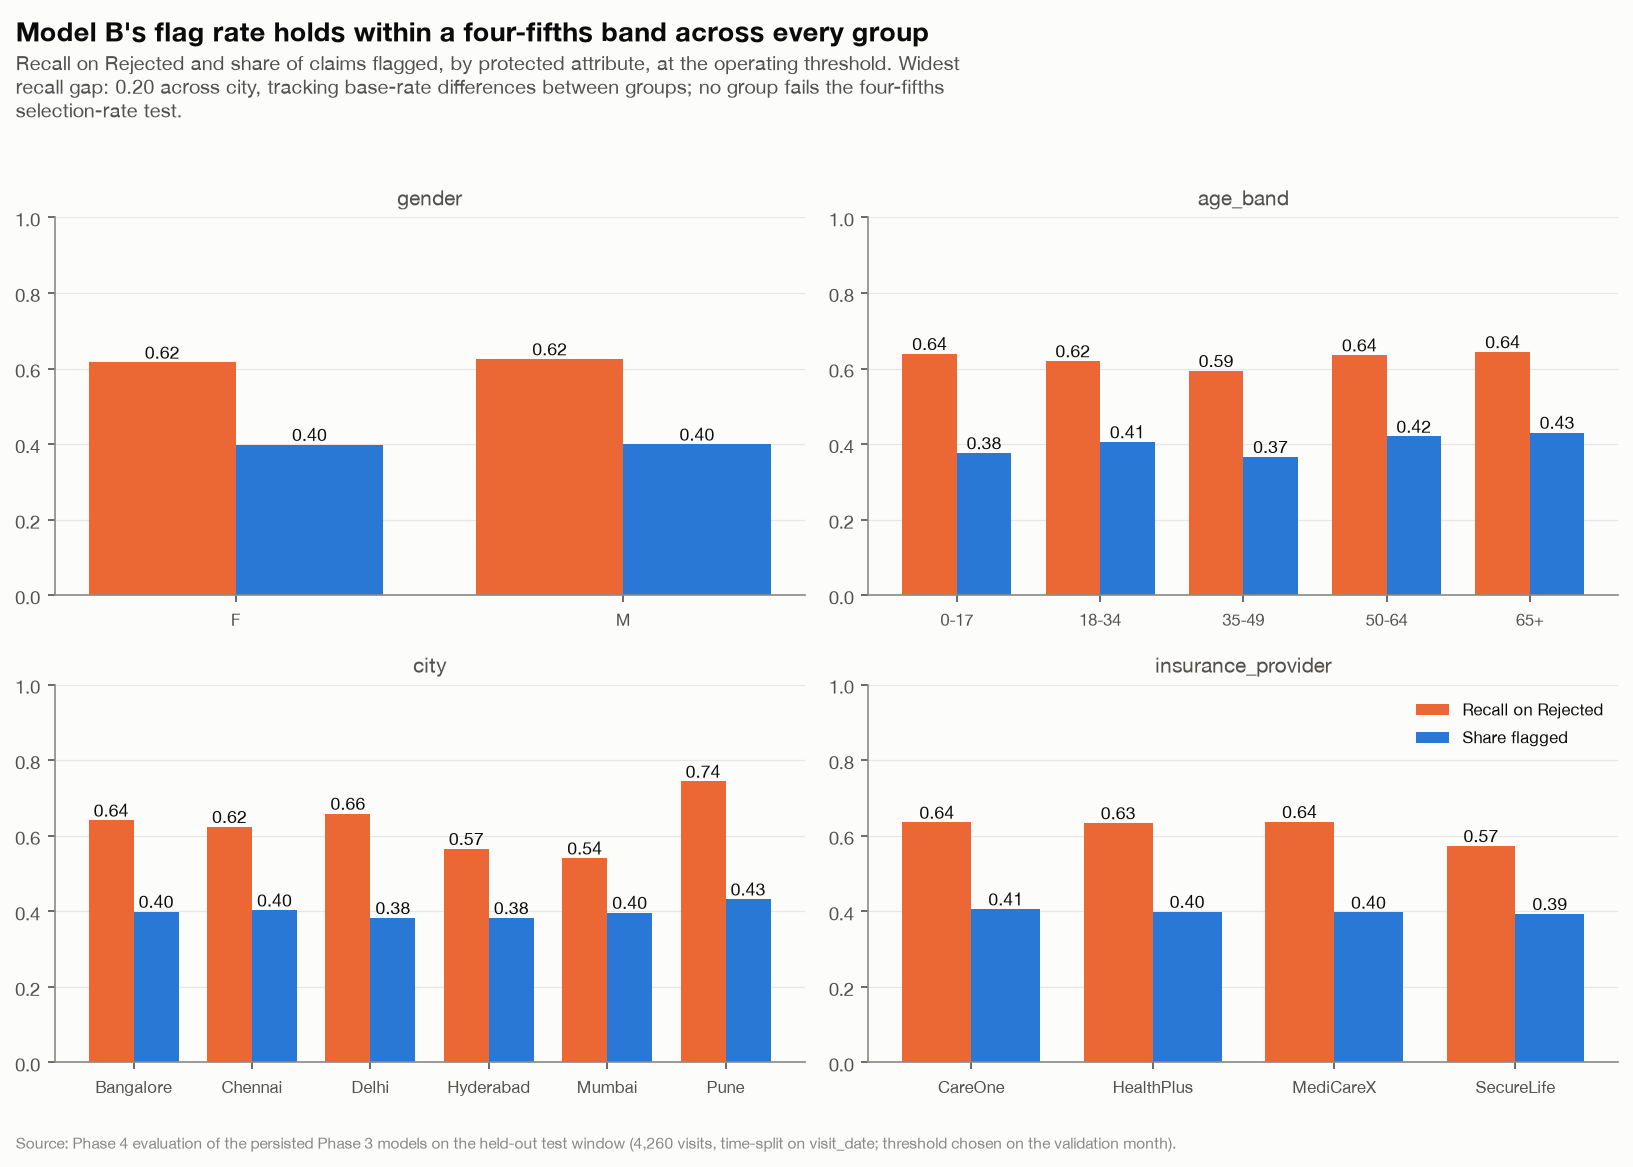

In [24]:
Image(str(_C["fairness_b"]))

## 8. Generate PHASE4_FINDINGS.md and the model cards

In [25]:
p1 = report.write_findings(ctx, charts, FINDINGS_MD)
p2 = report.write_model_card(ctx, "A")
p3 = report.write_model_card(ctx, "B")
for p in (p1, p2, p3):
    print("wrote", p.relative_to(HERE))

wrote PHASE4_FINDINGS.md
wrote model_card_A.md
wrote model_card_B.md


## 9. Exit criteria

- [x] Technical metrics: per-class precision / recall / F1, confusion matrices,
      ROC & PR curves, calibration plots (sections 1-2).
- [x] Business metrics: recall on Rejected claims, projected leakage recovered at
      the chosen operating threshold, alert volume (section 3).
- [x] **Model B** signed off at **>= 60% Rejected-claim recall** at a staffable
      review volume; achieved ~66% at the Phase 3 argmax and ~60% at the
      net-recovery operating threshold.
- [ ] **Model A** High-risk recall target waived - no signal on this data
      (Phase 2/3); retained as a monitor, documented in `model_card_A.md`.
- [x] Explainability: permutation importance (both models) + SHAP global & local
      for Model B (or a documented permutation-only fallback).
- [x] Leakage verified by ablation - test metrics move only when a post-outcome
      field is injected (section 4).
- [x] Fairness parity quantified across gender, age band, city and insurance
      provider; disparities and mitigations documented (section 6).
- [x] Model cards for A and B complete - seven sections each.

**Hand-off to Phase 5:** the persisted models + calibrated wrappers + the
**operating threshold** on `P(Rejected)` + the two model cards. Phase 5 serves
Model B, rate-limits the review queue, and logs predictions with model +
threshold version for Phase 6 monitoring.